# 01. Środowisko
Agent steruje łodzią podwodną i zbiera skarby z dna oceanu. Ma do dyspozycji ograniczony zapas tlenu, któy może uzupełnić wypływając na powierzchnię. Łódź ma niewielki zasięg widzenia, który może tymczasowo zwiększyć używając aktywnego sonaru kosztem większego zużycia tlenu. Gra kończy się po zebraniu wszystkich rozrzuconych na mapie skrzyń (wygrana), albo po uderzeniu w dno, krawędź boczną lub wyczerpanie tlenu (przegrana).

## Potrzebne biblioteki

In [3]:
from enum import Enum
import gymnasium as gym
from gymnasium import spaces
import pygame
import numpy as np

## Klasa środowiska

### 1. Przestrzeń Akcji

| Indeks | Nazwa  | Zakres       | Opis |
| :----- | :----- | :----------- | :--- |
| 0      | Engine | [-1.0, 1.0]  | Przyspieszenie (dodatnie: przód, ujemne: tył) |
| 1      | Torque | [-1.0, 1.0]  | Moment obrotowy (rotacja łodzi) |
| 2      | Sonar  | [0.0, 1.0]   | Aktywacja sonaru (wartość > 0.5 włącza sonar) |

### 2. Przestrzeń Obserwacji

Wektor 23 wartości zawiera:
* **Fizyka łodzi (5):** Pozycja X/Y, moment obrotowy, kąt (znormalizowany), prędkość.
* **Status systemów (2):** Poziom tlenu (0.0-1.0), status aktywności sonaru (0/1).
* **Nawigacja (4):** Widoczność skarbu (0/1), wektor celu (X, Y), aktualny horyzont widzenia.
* **Sensory (12):** Odczyty `sonar_readings` informujące o dystansie do przeszkód w 12 kierunkach.

### 3. Dane wyjściowe
Po każdym kroku środowisko zwraca:
* **Observation:** Wektor stanu (23 elementy).
* **Reward:** Suma nagród za zbliżanie się do celu, zebranie skarbu oraz kary za czas, tlen i kolizje.
* **Terminated:** `True`, jeśli tlen spadnie do 0 lub nastąpi kolizja ze skałami.
* **Truncated:** `True`, jeśli osiągnięto limit kroków (jeśli zdefiniowany).
* **Info:** Słownik zawierający `distance_to_treasure` oraz `oxygen_left`.

### 4. System Nagród

| Składowa | Wartość | Opis |
| :--- | :--- | :--- |
| **Kara czasowa** | `-5` | Przyznawana w każdym kroku, aby wymusić pośpiech i oszczędność tlenu. |
| **Postęp (Shaping)** | `delta * multiplier` | Nagroda za zbliżanie się do skarbu. `delta` to różnica dystansu od skarbu w poprzednim kroku a dystansem w obecnym. |
| **Eksploracja** | `+10.0` | Przyznawana jednorazowo za wpłynięcie do nowego sektora siatki. |
| **Zbiór skarbu** | `+2500.0` | Przyznawana, gdy dystans do skarbu spadnie poniżej 35 jednostek. |
| **Ukończenie** | `+5000.0` | Bonus za wykonanie całego zadania (zebranie wszystkich celów). |
| **Koniec tlenu** | `-1500.0` | Kara za doprowadzenie do stanu `oxygen <= 0`. |
| **Kolizja** | `-2000.0` | Kara za uderzenie w dno lub ściany. |

In [19]:
class DeepSeaScavenger(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 30}

    def __init__(self, render_mode=None):
        self.window_size = 768
        self.x, self.y = 100.0, 150.0
        self.ship_width = 40.0
        self.ship_height = 20.0
        self.torque, self.angle, self.speed = 0.0, 0.0, 0.0
        self.font = None
        self.max_oxygen = 100.0
        self.oxygen = 100.0
        self.is_sonar_active = 0.0
        self.sonar_readings = np.zeros(12, dtype=np.float32)
        self.treasure_pos = []
        self.treasures_collected = 0
        self.floor_heights = None
        self.prev_treasure_dist = float("inf")

        self.observation_space = spaces.Box(
                    low=-np.inf, high=np.inf, 
                    shape=(23,),
                    dtype=np.float32
                )

        """
        Action Space
            - Engine
            - Torque
            - Active sonar
        """
        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, 0.0]), 
            high=np.array([1.0, 1.0, 1.0]), 
            dtype=np.float32
        )

        assert render_mode is None or render_mode in self.metadata["render_modes"]
        self.render_mode = render_mode

        """
            If human-rendering is used, `self.window` will be a reference
            to the window that we draw to. `self.clock` will be a clock that is used
            to ensure that the environment is rendered at the correct framerate in
            human-mode. They will remain `None` until human-mode is used for the
            first time.
        """
        self.window = None
        self.clock = None
        self.static_canvas = None
        self.bubbles = []

    def _get_obs(self, horizon):
        nearest_treasure_dist = float('inf')
        target_vector = np.array([0.0, 0.0], dtype=np.float32)
        is_visible = 0.0

        if self.treasure_pos:
            my_pos = np.array([self.x, self.y])
            dists = [np.linalg.norm(my_pos - np.array(t)) for t in self.treasure_pos]
            min_idx = np.argmin(dists)
            nearest_treasure_dist = dists[min_idx]

            if nearest_treasure_dist <= horizon:
                is_visible = 1.0
                target_vector[0] = (self.treasure_pos[min_idx][0] - self.x) / horizon
                target_vector[1] = (self.treasure_pos[min_idx][1] - self.y) / horizon

        state = np.array([
            self.x / self.window_size,
            self.y / self.window_size,
            self.torque, 
            self.angle / (2 * np.pi),
            self.speed / 1.25,
            self.oxygen / 100.0,
            float(self.is_sonar_active),
            is_visible,
            target_vector[0],
            target_vector[1],
            horizon / 150.0
        ], dtype=np.float32)
        
        return np.concatenate([state, self.sonar_readings]).astype(np.float32)

    def _get_info(self):
            if not self.treasure_pos:
                return {
                    "distance_to_treasure": 0.0,
                    "treasures_collected": self.treasures_collected
                }
    
            return {
                "distance_to_treasure": np.linalg.norm(
                    np.array([self.x, self.y]) - self.treasure_pos
                ),
                "oxygen_left": self.oxygen
            }

    def _get_distance_to_nearest_treasure(self):
        if not self.treasure_pos:
            return 0.0
        my_pos = np.array([self.x, self.y])
        dists = [np.linalg.norm(my_pos - np.array(t)) for t in self.treasure_pos]
        return min(dists)

    def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            
            self.x = 100.0
            self.y = 150.0
            self.torque = 0.0
            self.angle = 0.0
            self.speed = 0.0
            
            self.oxygen = 100.0
            self.max_oxygen = 100.0
            self.is_sonar_active = 0.0
            self.sonar_readings = np.zeros(12, dtype=np.float32)

            self.treasure_pos = []
            self.treasures_collected = 0

            self.grid_size = 50
            cols = self.window_size // self.grid_size
            rows = self.window_size // self.grid_size
            self.visited_grid = np.zeros((cols, rows), dtype=bool)

            num_points = 12
            x_points = np.linspace(0, self.window_size, num_points)
            y_points = 600 + self.np_random.uniform(-150, 100, num_points)
            x_all = np.arange(self.window_size)
            base_terrain = np.interp(x_all, x_points, y_points)

            sine_waves = (
                np.sin(x_all * 0.02) * 20 + 
                np.sin(x_all * 0.05) * 10
            )

            noise = self.np_random.normal(0, 3, self.window_size)
            self.floor_heights = base_terrain + sine_waves + noise
            self.floor_heights = np.clip(self.floor_heights, 100, self.window_size - 50)


            for _ in range(3):
                treasure_x = self.np_random.integers(50, self.window_size - 50)
                treasure_y = self.floor_heights[int(treasure_x)] - 20
                self.treasure_pos.append((treasure_x, treasure_y))

            self.static_canvas = None
            self.bubbles = []
            self._create_static_render()

            observation = self._get_obs(50.0)
            info = self._get_info()

            if self.render_mode == "human":
                self._render_frame()

            self.prev_treasure_dist = self._get_distance_to_nearest_treasure()
            return observation, info
    
    def _create_static_render(self):
            if self.static_canvas is not None:
                return

            bg = pygame.Surface((self.window_size, self.window_size), pygame.SRCALPHA)
            top_color = np.array((25, 70, 130), dtype=np.uint8)
            bottom_color = np.array((3, 12, 45), dtype=np.uint8)
            for y in range(self.window_size):
                ratio = y / self.window_size
                row_color = tuple((top_color * (1 - ratio) + bottom_color * ratio).astype(np.uint8))
                pygame.draw.line(bg, row_color, (0, y), (self.window_size, y))

            pygame.draw.rect(bg, (50, 160, 220, 180), pygame.Rect(0, 0, self.window_size, 100))
            for i in range(5):
                wave_x = int((i * 140) % self.window_size)
                pygame.draw.arc(bg, (180, 220, 240, 70), (wave_x - 90, 20, 180, 30), 3.14, 2 * 3.14, 2)

            seabed = [(0, self.window_size)]
            for x in range(0, self.window_size, 5):
                seabed.append((x, int(self.floor_heights[x])))
            seabed.append((self.window_size - 1, self.window_size))
            pygame.draw.polygon(bg, (110, 90, 40), seabed)
            pygame.draw.lines(bg, (80, 65, 30), False, seabed[1:-1], 4)

            self.static_canvas = bg

    def _check_collision(self):
        hw = self.ship_width / 2
        hh = self.ship_height / 2
        
        vertices = [
            (-hw, -hh), (hw, -hh), (hw, hh), (-hw, hh)
        ]
        
        cos_a = np.cos(self.angle)
        sin_a = np.sin(self.angle)
        
        for vx, vy in vertices:
            rx = vx * cos_a - vy * sin_a
            ry = vx * sin_a + vy * cos_a
            
            world_x = int(self.x + rx)
            world_y = self.y + ry
            
            if 0 <= world_x < self.window_size:
                if world_y >= self.floor_heights[world_x]:
                    return True
            else:
                 return True
        return False

    def _cast_rays(self, dist):
        num_rays = 12
        steps = 10

        angles = np.linspace(0, 2 * np.pi, num_rays, endpoint=False)
        dists = np.linspace(0, dist, steps)

        dx = np.sin(angles)[:, np.newaxis]
        dy = np.cos(angles)[:, np.newaxis]

        test_x_raw = self.x + dx * dists
        test_y = self.y + dy * dists

        test_x_idx = np.clip(test_x_raw.astype(int), 0, self.window_size - 1)

        is_wall_hit = (test_x_raw <= 0) | (test_x_raw >= self.window_size - 1)
        is_floor_hit = test_y >= self.floor_heights[test_x_idx]

        hits = is_wall_hit | is_floor_hit
        hit_indices = np.argmax(hits, axis=1)
        any_hit = np.any(hits, axis=1)

        readings = np.ones(num_rays, dtype=np.float32)
        readings[any_hit] = dists[hit_indices[any_hit]] / dist

        return readings
    
    def _get_nearest_treasure(self):
        if not self.treasure_pos:
            return None, float('inf')
        
        my_pos = np.array([self.x, self.y])
        distances = [np.linalg.norm(my_pos - np.array(t)) for t in self.treasure_pos]
        min_idx = np.argmin(distances)
        
        return self.treasure_pos[min_idx], distances[min_idx]

    def step(self, action):
            # Reading action
            engine = action[0]
            torque = action[1]
            sonar_req = action[2]

            # Physics
            self.angle += torque * 0.025
            self.speed += engine * 0.0425
            self.speed = np.clip(self.speed, -0.750, 1.25)
            
            # Updating the position of the submarine
            self.x += np.cos(self.angle) * self.speed
            self.y += np.sin(self.angle) * self.speed

            # Block swimming over the surface and regenerate oxygen
            surface_limit = 100 + (self.ship_height / 2)
            if self.y < surface_limit:
                self.y = surface_limit
                self.vy = 0

            if self.y - (self.ship_height / 2) <= 101:
                self.oxygen += 1 
                if self.oxygen > self.max_oxygen:
                    self.oxygen = self.max_oxygen

            # Sonar and oxygen
            self.is_sonar_active = 1.0 if sonar_req > 0.5 else 0.0
            self.oxygen -= 0.025
            horizon = 50
            if self.is_sonar_active:
                self.oxygen -= 0.225
                horizon = 150
                self.sonar_readings = self._cast_rays(dist=horizon)
            else:
                self.sonar_readings = self._cast_rays(dist=horizon)

            # Animated bubbles rising behind the sub
            if self.render_mode == "human":
                for bubble in self.bubbles:
                    bubble["y"] -= bubble["speed"]
                    bubble["x"] += bubble["drift"]
                    bubble["alpha"] = max(0, bubble["alpha"] - 1)
                    bubble["life"] -= 1
                self.bubbles = [bubble for bubble in self.bubbles if bubble["life"] > 0 and bubble["alpha"] > 0 and bubble["y"] > 100]

                if len(self.bubbles) < 25 and abs(self.speed) > 0.05:
                    for _ in range(2):
                        drift = float(self.np_random.uniform(-0.35, 0.35))
                        speed = float(self.np_random.uniform(0.9, 1.8))
                        radius = int(self.np_random.integers(2, 5))
                        offset_x = float(self.np_random.uniform(-6, 6))
                        offset_y = float(self.np_random.uniform(4, 12))
                        self.bubbles.append({
                            "x": self.x - np.cos(self.angle) * offset_y + np.sin(self.angle) * offset_x,
                            "y": self.y - np.sin(self.angle) * offset_y - np.cos(self.angle) * offset_x,
                            "radius": radius,
                            "speed": speed,
                            "drift": drift,
                            "alpha": 180,
                            "life": 40 + int(self.np_random.integers(0, 20))
                        })

            # Check for termination condition (hit the bottom or ran out of oxygen)
            terminated = self.oxygen <= 0 or self._check_collision()
            completed = len(self.treasure_pos) == 0
            
            # Reward
            current_dist = self._get_distance_to_nearest_treasure()
            distance_delta = self.prev_treasure_dist - current_dist
            self.prev_treasure_dist = current_dist
            multiplier = 1.0 + (500 / (current_dist + 50)) * 7

            reward = -5 + (distance_delta * multiplier)

            grid_x = int(np.clip(self.x // self.grid_size, 0, self.visited_grid.shape[0] - 1))
            grid_y = int(np.clip(self.y // self.grid_size, 0, self.visited_grid.shape[1] - 1))

            exploration_reward = 0
            if not self.visited_grid[grid_x, grid_y]:
                self.visited_grid[grid_x, grid_y] = True
                exploration_reward = 10.0

            reward += exploration_reward

            if terminated:
                if self.oxygen <= 0:
                    reward = -1500.0
                else:
                    reward = -2000.0

            if completed:
                reward = 5000.0

            # Collecting treasuers
            for i in range(len(self.treasure_pos) - 1, -1, -1):
                curr_treasure_pos = self.treasure_pos[i]
                dist = np.linalg.norm(np.array([self.x, self.y]) - curr_treasure_pos)
                
                if dist < 35.0:
                    reward += 2500.0
                    self.treasures_collected += 1
                    self.oxygen = min(self.max_oxygen, self.oxygen + 20)
                    self.treasure_pos.pop(i)
                    _, new_dist = self._get_nearest_treasure()
                    self.prev_treasure_dist = new_dist

            # Preparing info
            observation = self._get_obs(horizon)
            info = self._get_info()

            if self.render_mode == "human":
                self._render_frame()

            return observation, reward, (terminated or completed), False, info

    def render(self):
        if self.render_mode == "rgb_array":
            return self._render_frame()

    def _render_frame(self):
            if self.window is None and self.render_mode == "human":
                pygame.init()
                pygame.display.init()
                self.window = pygame.display.set_mode((self.window_size, self.window_size))
            if self.clock is None and self.render_mode == "human":
                self.clock = pygame.time.Clock()

            if self.static_canvas is None:
                self._create_static_render()

            canvas = self.static_canvas.copy()

            # Submarine body
            sub_w = int(self.ship_width * 1.8)
            sub_h = int(self.ship_height * 1.5)
            sub_surface = pygame.Surface((sub_w, sub_h), pygame.SRCALPHA)
            pygame.draw.ellipse(sub_surface, (20, 90, 140), pygame.Rect(0, 0, sub_w, sub_h))
            pygame.draw.ellipse(sub_surface, (10, 45, 80), pygame.Rect(0, 0, sub_w, sub_h), 4)
            pygame.draw.rect(sub_surface, (25, 110, 175), pygame.Rect(sub_w // 3, sub_h // 4, sub_w // 2, sub_h // 2), border_radius=12)
            pygame.draw.circle(sub_surface, (170, 220, 240), (sub_w * 3 // 4, sub_h // 2), sub_h // 4)
            pygame.draw.circle(sub_surface, (20, 40, 60), (sub_w * 3 // 4, sub_h // 2), sub_h // 5)
            pygame.draw.polygon(sub_surface, (20, 90, 140), [(0, sub_h // 2), (sub_w // 6, sub_h // 3), (sub_w // 6, sub_h * 2 // 3)])
            pygame.draw.rect(sub_surface, (20, 90, 140), pygame.Rect(sub_w // 2 - 4, 0, 8, sub_h // 3), border_radius=3)
            pygame.draw.circle(sub_surface, (170, 220, 240), (sub_w // 2, 4), 4)

            rotated_surf = pygame.transform.rotate(sub_surface, -np.degrees(self.angle))
            rect = rotated_surf.get_rect(center=(int(self.x), int(self.y)))
            canvas.blit(rotated_surf, rect.topleft)

            for treasure in self.treasure_pos:
                tx, ty = int(treasure[0]), int(treasure[1])
                chest_w, chest_h = 22, 16
                base_rect = pygame.Rect(tx - chest_w // 2, ty - chest_h // 2, chest_w, chest_h)
                pygame.draw.rect(canvas, (210, 145, 60), base_rect)
                pygame.draw.rect(canvas, (170, 100, 30), base_rect, 2)
                lid = pygame.Rect(base_rect.x, base_rect.y - 6, chest_w, 8)
                pygame.draw.rect(canvas, (180, 120, 50), lid)
                pygame.draw.rect(canvas, (140, 90, 25), lid, 2)
                pygame.draw.circle(canvas, (200, 200, 100), (tx, ty), 4)
                pygame.draw.line(canvas, (140, 90, 25), (tx, ty - 4), (tx, ty + 4), 2)

            # Sonar bubble and rays
            if self.is_sonar_active > 0.5:
                sonar_surf = pygame.Surface((self.window_size, self.window_size), pygame.SRCALPHA)
                pygame.draw.circle(sonar_surf, (120, 220, 220, 30), (int(self.x), int(self.y)), 150, 2)
                pygame.draw.circle(sonar_surf, (120, 220, 220, 20), (int(self.x), int(self.y)), 100, 1)
                canvas.blit(sonar_surf, (0, 0))

            base_range = 150.0 if self.is_sonar_active > 0.5 else 50.0

            # Animated rising bubbles behind the submarine
            trail_surface = pygame.Surface((self.window_size, self.window_size), pygame.SRCALPHA)
            for bubble in self.bubbles:
                alpha = max(0, min(255, int(bubble["alpha"])))
                color = (200, 230, 255, alpha)
                pygame.draw.circle(trail_surface, color, (int(bubble["x"]), int(bubble["y"])), bubble["radius"])
            canvas.blit(trail_surface, (0, 0))

            # Visibility mask for human play: only sonar circle + surface are clear
            if self.render_mode == "human":
                view_radius = int(base_range + 30)
                mask_overlay = pygame.Surface((self.window_size, self.window_size), pygame.SRCALPHA)
                mask_overlay.fill((0, 0, 0, 220))
                pygame.draw.rect(mask_overlay, (0, 0, 0, 0), pygame.Rect(0, 0, self.window_size, 100))
                pygame.draw.circle(mask_overlay, (0, 0, 0, 0), (int(self.x), int(self.y)), view_radius)
                pygame.draw.circle(mask_overlay, (120, 220, 255, 40), (int(self.x), int(self.y)), view_radius, 2)
                canvas.blit(mask_overlay, (0, 0))

            # HUD panel
            if self.font is None:
                pygame.font.init()
                self.font = pygame.font.SysFont("Arial", 22, bold=True)

            hud_bg = pygame.Surface((260, 90), pygame.SRCALPHA)
            hud_bg.fill((10, 10, 30, 180))
            pygame.draw.rect(hud_bg, (80, 180, 220, 200), hud_bg.get_rect(), border_radius=10)
            pygame.draw.rect(hud_bg, (20, 120, 170, 200), hud_bg.get_rect(), 2, border_radius=10)
            canvas.blit(hud_bg, (20, 20))

            oxygen_text = f"Oxygen: {int(self.oxygen)} / {int(self.max_oxygen)}"
            sonar_text = "SONAR: ON" if self.is_sonar_active > 0.5 else "SONAR: OFF"
            treasure_text = f"Crates: {len(self.treasure_pos)}"

            oxygen_surface = self.font.render(oxygen_text, True, (220, 240, 255))
            sonar_surface = self.font.render(sonar_text, True, (200, 220, 255))
            treasure_surface = self.font.render(treasure_text, True, (220, 220, 140))
            canvas.blit(oxygen_surface, (32, 28))
            canvas.blit(sonar_surface, (32, 52))
            canvas.blit(treasure_surface, (32, 76))

            # Oxygen bar
            bar_x, bar_y, bar_w, bar_h = 32, 98, 216, 12
            pygame.draw.rect(canvas, (40, 60, 80), (bar_x, bar_y, bar_w, bar_h), border_radius=6)
            fill_w = int(bar_w * max(0.0, min(1.0, self.oxygen / self.max_oxygen)))
            bar_color = (80, 220, 120) if self.oxygen > 40 else (240, 190, 40) if self.oxygen > 15 else (240, 80, 80)
            pygame.draw.rect(canvas, bar_color, (bar_x, bar_y, fill_w, bar_h), border_radius=6)
            pygame.draw.rect(canvas, (180, 220, 240), (bar_x, bar_y, bar_w, bar_h), 2, border_radius=6)

            # Rendering
            if self.render_mode == "human":
                self.window.blit(canvas, canvas.get_rect())
                pygame.event.pump()
                pygame.display.update()
                self.clock.tick(self.metadata["render_fps"])
            else:
                return np.transpose(
                    np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2)
                )

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

## Sterowanie jako człowiek

In [ ]:
env = DeepSeaScavenger(render_mode="human")
obs, info = env.reset()

running = True
while running:
    keys = pygame.key.get_pressed()

    action = [0.0, 0.0, 0.0]

    if keys[pygame.K_UP]:    action[0] = 1.0
    if keys[pygame.K_DOWN]:  action[0] = -1.0
    if keys[pygame.K_LEFT]:  action[1] = -1.0
    if keys[pygame.K_RIGHT]: action[1] = 1.0
    if keys[pygame.K_SPACE]: action[2] = 1.0

    obs, reward, terminated, truncated, info = env.step(np.array(action, dtype=np.float32))

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    if terminated or truncated:
        obs, info = env.reset()

env.close()


# 02. Trening agenta

## Potrzebne biblioteki

In [11]:
import os
import gymnasium as gym
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

## Trenowanie agenta i zapis krzywej uczenia

In [ ]:
models_dir = "models/SAC"
logdir = "logs"
os.makedirs(models_dir, exist_ok=True)
os.makedirs(logdir, exist_ok=True)


class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []
        self.current = 0

    def _on_step(self) -> bool:
        reward = self.locals.get("reward")
        done = self.locals.get("done")

        if reward is None:
            reward = self.locals.get("rewards")

        if reward is not None:
            if isinstance(reward, (np.ndarray, list)):
                reward = reward[0]
            self.current += float(reward)

        if done is None:
            done = self.locals.get("dones")

        if done is not None:
            finished = done[0] if isinstance(done, (np.ndarray, list)) else done
            if finished:
                self.rewards.append(self.current)
                self.current = 0

        return True

env = DeepSeaScavenger()
model = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    buffer_size=100000,
    learning_starts=1000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    ent_coef="auto",
    verbose=1
)

logger = RewardLogger()
TIMESTEPS = 1000

for i in range(1, 201):
    model.learn(total_timesteps=TIMESTEPS, reset_num_timesteps=False, callback=logger)
    if i % 10 == 0:
        model.save(f"{models_dir}/{TIMESTEPS*i}")

rewards = logger.rewards
window_size = 20
if len(rewards) >= window_size:
    rewards_smoothed = np.convolve(rewards, np.ones(window_size) / window_size, mode="valid")
    plt.figure(figsize=(10, 6))
    plt.plot(range(window_size - 1, len(rewards)), rewards_smoothed, color='blue', linewidth=2)
    plt.savefig(f"{logdir}/sac_learning_curve.png")

## Krzywa uczenia
Oś X - Epizod, Oś Y - Uśredniona nagroda

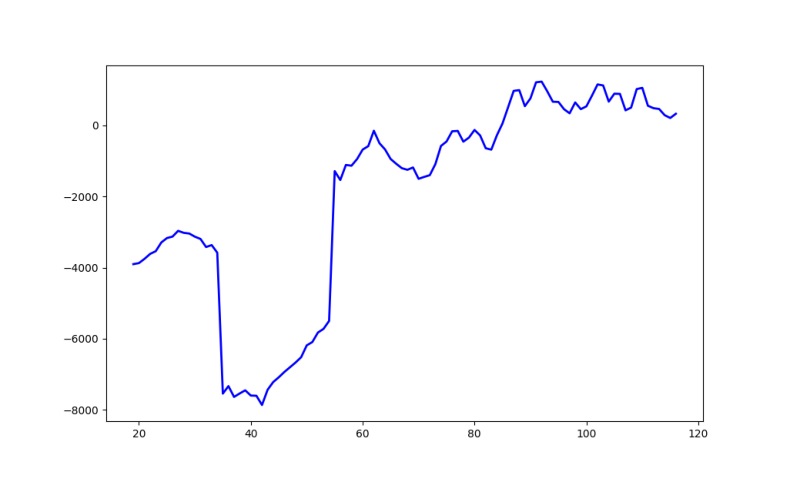

In [ ]:
file_path = "logs/sac_learning_curve.png"

img = mpimg.imread(file_path)
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

# 03. Ewaluacja

## Potrzebne importy

In [ ]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import SAC

## Funkcja ewaluacyjna

In [22]:
def evaluate(model, episodes=5):
    for ep in range(episodes):
        obs, info = env.reset()
        done = False

        while not done:
            env.render()

            action, _states = model.predict(obs, deterministic=True)

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

    env.close()

## Model z początku treningu

In [39]:
env = DeepSeaScavenger(render_mode="human")
model_path = "models/SAC/5000.zip"
model = SAC.load(model_path, env=env)
evaluate(model, episodes=3)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


KeyboardInterrupt: 

## Model ze środka treningu

In [24]:
env = DeepSeaScavenger(render_mode="human")
model_path = "models/SAC/45000.zip"
model = SAC.load(model_path, env=env)
evaluate(model, episodes=3)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


## Model z końca treningu

In [41]:
env = DeepSeaScavenger(render_mode="human")
model_path = "models/SAC/98000.zip"
model = SAC.load(model_path, env=env)
evaluate(model, episodes=3)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
